In [36]:
from pychnosz import info, add_OBIGT, mod_OBIGT, reset, subcrt, basis, species, equilibrate, affinity, diagram, ZC
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

info_character: found Gln(aq); also available in cr
info_character: found Arg(aq); also available in cr


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'Ile'),
  Text(1, 0, 'Leu'),
  Text(2, 0, 'Val'),
  Text(3, 0, 'Lys'),
  Text(4, 0, 'Phe'),
  Text(5, 0, 'Pro'),
  Text(6, 0, 'Met'),
  Text(7, 0, 'Tyr'),
  Text(8, 0, 'Trp'),
  Text(9, 0, 'Thr'),
  Text(10, 0, 'Ala'),
  Text(11, 0, 'Arg'),
  Text(12, 0, 'Glu'),
  Text(13, 0, 'Gln'),
  Text(14, 0, 'Cys'),
  Text(15, 0, 'His'),
  Text(16, 0, 'Ser'),
  Text(17, 0, 'Asn'),
  Text(18, 0, 'Asp'),
  Text(19, 0, 'Gly')])

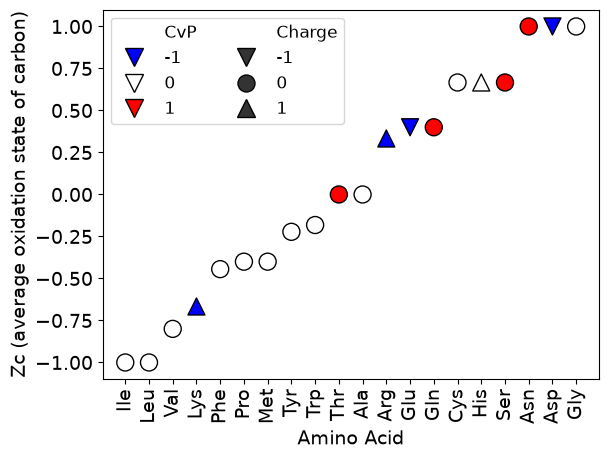

In [ ]:
aas    = ['Ala','Cys','Asp','Glu','Phe','Gly','His','Ile','Lys','Leu','Met','Asn','Pro','Gln','Arg','Ser','Thr','Val','Trp','Tyr']
charge = [    0,    0,   -1,   -1,    0,    0,    1,    0,    1,    0,    0,    0,    0,    0,    1,    0,    0,    0,    0,    0]
CvP    = [    0,    0,   -1,   -1,    0,    0,    0,    0,   -1,    0,    0,    1,    0,    1,   -1,    1,    1,    0,    0,    0] # from Suhre and Claverie (2003)
Zcs    = []
for aa in aas:
    Zcs.append(ZC(info(info(aa))['formula'][0]))

df = pd.DataFrame({'Amino Acid': aas, 'ZC': Zcs, 'Charge': charge, 'CvP': CvP})
df.sort_values(by='ZC', ascending=True, inplace=True)

plt.rcParams.update({'font.size': 14})
sns.scatterplot(data=df, x='Amino Acid', y='ZC', 
                hue='CvP', palette='bwr', 
                style='Charge', markers={-1: 'v', 1: '^', 0: 'o'},
                s=150, edgecolor='black')
plt.legend(ncol=2, fontsize=12)
plt.ylabel('Zc (average oxidation state of carbon)')
plt.xlabel('Amino Acid')
plt.xticks(rotation=90)


- Suhre et al. (2003) and references therein : the proportions of charged (Lys, Arg, Glu, Asp) versus polar (non-charged) (Thr, Gln, Ser, Asn) amino acids (CvP-bias) is an empirical, signature of the proteome of hyperthermophilic organisms (Tgrowth >80 °C). 
- Dick (2014) : Higher temperatures are often associated with more reducing environments: seawater vs hydrothermal fluids
- => charged amino acids (Lys, Arg, Glu, Asp) are more oxidized that polar amino acids (Thr, Gln, Ser, Asn) so the 'empirical' CvP-bias may actually be related to evolutionary adaptation: the increase of charged amino acids (high CvP difference) in the proteome of hyperthermophilic organisms (Tgrowth >80 °C) produce a decrease in oxidation state of carbon of the proteins, which results in energetic savings for overall protein synthesis in hot, reducing environments.